<a href="https://colab.research.google.com/github/TanujaMore27/Deep-Learning/blob/main/10_1_early_stopping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Early Stopping in Neural Networks :


* it gives the point where to stop where the model starts overfitting .
* in keras there is a feature of call back for early stopping.
*** it contains some parameters such as
- monitor : on which parameter we are doing early stopping
- min_detla : min change in the monitored quantity to qualify as improvement
- patience : no. of epochs with no improvements after which training will be stopped
- verbose : verbosity mode , 0 or 1. mode 0 is silent and mode 1 displays message when the callback takes an action.
- mode : one of the auto,min,max. in "min" mode training will be stop when the quantity monitored has stop decreasing, in "max" mode it will stop when quantity monitored has stopped increasing , in "auto" mode the direction is automatically inferred from name of the monitored quantity.
- baseline : baseline value for the monitored quantity.training will stop if the model doesn't show improvement over the baseline.
- restore_best_weights : whether to restore model weights from the epoch with the with the best value of the monitored quantity. if false the model weights obtained at the last step of training are used. an epoch will be restored regardless of the performance relative to the baseline.if no epoch improves on baseline,training will run for patience epochs and restore weights from the best epoch in that set.

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

In [ ]:
x,y = make_circles(n_samples = 100,noise=0.1,random_state=1)

<Axes: >

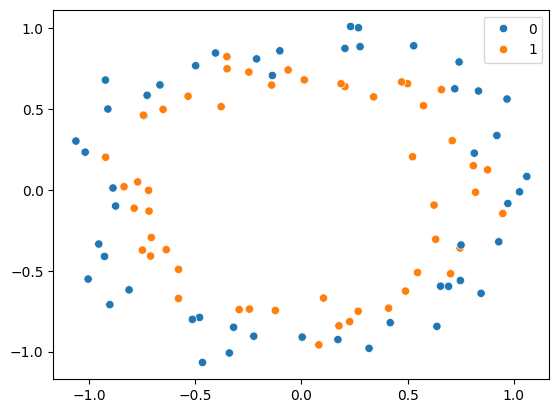

In [ ]:
sns.scatterplot(x=x[:,0],y=x[:,1],hue=y)

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=2)

In [ ]:
model = Sequential()

model.add(Dense(256,input_dim=2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
history = model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=3500,verbose=0)

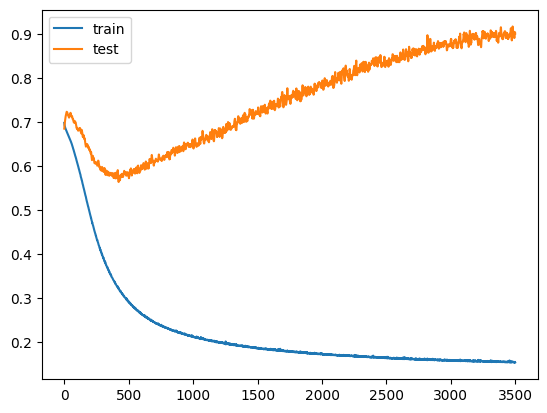

In [ ]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 719us/step


<function matplotlib.pyplot.show(close=None, block=None)>

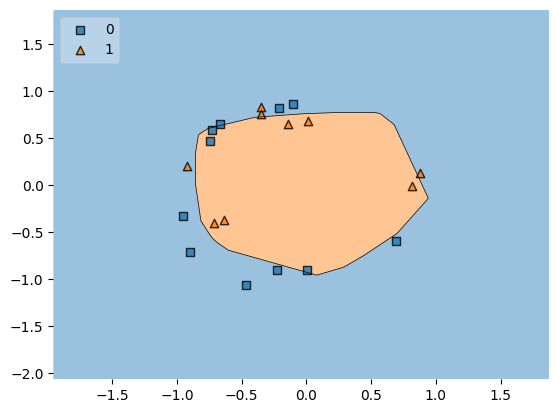

In [ ]:
plot_decision_regions(x_test,y_test.ravel(),clf = model,legend=2)
plt.show

### Early Stopping

In [ ]:
model = Sequential()

model.add(Dense(256,input_dim=2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
callback = EarlyStopping(
    monitor='val_loss',
    min_delta=0.00001,
    patience=10,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=False
    )

In [ ]:
history = model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=3500,verbose=0,callbacks=callback)

Epoch 10: early stopping


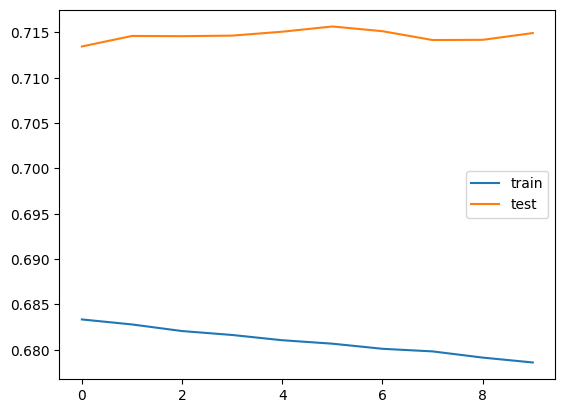

In [ ]:
plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 719us/step


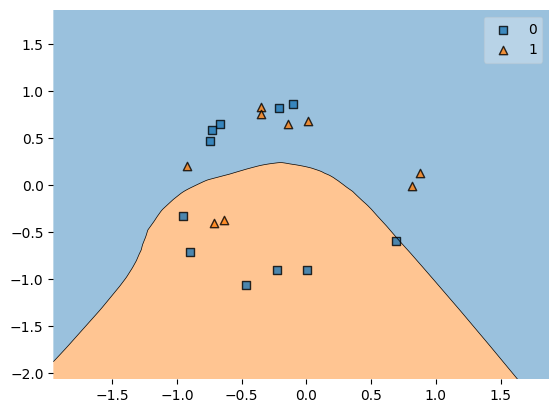

In [ ]:
plot_decision_regions(x_test,y_test.ravel(),clf=model,legend=1)
plt.show()